In [1]:
import pandas as pd
import numpy as np
from pprint import pprint

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
melanoma = pd.read_csv('/content/drive/MyDrive/BRACU_Course/Current Course/CSE422/Labs/Lab06/Melanoma TFRecords 256x256.csv')
melanoma.head()


,image_name,patient_id,sex,age_approx,anatom_site_general_challenge,diagnosis,benign_malignant,target,tfrecord,width,height,patient_code
0,ISIC_2637011,IP_7279968,male,45.0,head/neck,unknown,benign,0,0,6000,4000,0
1,ISIC_0015719,IP_3075186,female,45.0,upper extremity,unknown,benign,0,0,6000,4000,1
2,ISIC_0052212,IP_2842074,female,50.0,lower extremity,nevus,benign,0,6,1872,1053,2
3,ISIC_0068279,IP_6890425,female,45.0,head/neck,unknown,benign,0,0,1872,1053,3
4,ISIC_0074268,IP_8723313,female,55.0,upper extremity,unknown,benign,0,11,6000,4000,4


In [4]:
melanoma.shape

(33126, 12)

In [14]:
melanoma.isnull().sum()

sex                              0
age_approx                       0
anatom_site_general_challenge    0
diagnosis                        0
benign_malignant                 0
target                           0
dtype: int64

In [6]:
melanoma = melanoma.drop(['patient_id', 'patient_code', 'width', 'height', 'tfrecord', 'image_name'], axis = 1)
melanoma.shape

(33126, 6)

In [11]:
melanoma = melanoma.dropna(axis = 0, subset=['sex'])
melanoma.shape

(32531, 6)

In [12]:
melanoma['anatom_site_general_challenge'].unique()

array(['head/neck', 'upper extremity', 'lower extremity', 'torso',
       'palms/soles', 'oral/genital'], dtype=object)

In [13]:
melanoma['sex'] = melanoma['sex'].map({'female':0,'male':1}) 
melanoma.head()

,sex,age_approx,anatom_site_general_challenge,diagnosis,benign_malignant,target
0,1,45.0,head/neck,unknown,benign,0
1,0,45.0,upper extremity,unknown,benign,0
2,0,50.0,lower extremity,nevus,benign,0
3,0,45.0,head/neck,unknown,benign,0
4,0,55.0,upper extremity,unknown,benign,0


In [16]:
from sklearn.impute import SimpleImputer

impute = SimpleImputer(missing_values=np.nan, strategy='mean')

impute.fit(melanoma[['sex']])

melanoma['sex'] = impute.transform(melanoma[['sex']])

In [17]:
cat1 = pd.get_dummies(melanoma['anatom_site_general_challenge'])
cat2 = pd.get_dummies(melanoma['diagnosis'])
cat3 = pd.get_dummies(melanoma['benign_malignant'])
melanoma = melanoma.join(cat1)
melanoma = melanoma.join(cat2)
melanoma = melanoma.join(cat3)

melanoma

,sex,age_approx,anatom_site_general_challenge,diagnosis,benign_malignant,target,head/neck,lower extremity,oral/genital,palms/soles,...,cafe-au-lait macule,lentigo NOS,lichenoid keratosis,melanoma,nevus,seborrheic keratosis,solar lentigo,unknown,benign,malignant
0,1.0,45.0,head/neck,unknown,benign,0,1,0,0,0,...,0,0,0,0,0,0,0,1,1,0
1,0.0,45.0,upper extremity,unknown,benign,0,0,0,0,0,...,0,0,0,0,0,0,0,1,1,0
2,0.0,50.0,lower extremity,nevus,benign,0,0,1,0,0,...,0,0,0,0,1,0,0,0,1,0
3,0.0,45.0,head/neck,unknown,benign,0,1,0,0,0,...,0,0,0,0,0,0,0,1,1,0
4,0.0,55.0,upper extremity,unknown,benign,0,0,0,0,0,...,0,0,0,0,0,0,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33121,1.0,50.0,torso,unknown,benign,0,0,0,0,0,...,0,0,0,0,0,0,0,1,1,0
33122,1.0,65.0,torso,unknown,benign,0,0,0,0,0,...,0,0,0,0,0,0,0,1,1,0
33123,1.0,20.0,lower extremity,unknown,benign,0,0,1,0,0,...,0,0,0,0,0,0,0,1,1,0
33124,1.0,50.0,lower extremity,unknown,benign,0,0,1,0,0,...,0,0,0,0,0,0,0,1,1,0


In [18]:
features = melanoma.drop(['target'], axis = 1)
target = melanoma[['target']]

In [19]:
features = features.drop(['anatom_site_general_challenge', 'diagnosis', 'benign_malignant'], axis = 1)
features

,sex,age_approx,head/neck,lower extremity,oral/genital,palms/soles,torso,upper extremity,atypical melanocytic proliferation,cafe-au-lait macule,lentigo NOS,lichenoid keratosis,melanoma,nevus,seborrheic keratosis,solar lentigo,unknown,benign,malignant
0,1.0,45.0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0
1,0.0,45.0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,1,0
2,0.0,50.0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0
3,0.0,45.0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0
4,0.0,55.0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33121,1.0,50.0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,1,0
33122,1.0,65.0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,1,0
33123,1.0,20.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0
33124,1.0,50.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0


In [20]:
###defining entropy
def entropy(target_col):
    elements,counts = np.unique(target_col,return_counts=True)
    entropy = np.sum([(-counts[i]/np.sum(counts))*np.log2(counts[i]/np.sum(counts)) for i in range(len(elements))])
    return entropy

In [21]:
##Information Gain

def InfoGain(data,split_attribute_name,target_name="class_type"):
    total_entropy = entropy(data[target_name])
    vals,counts = np.unique(data[split_attribute_name],return_counts=True)
    #calculating the weighted entropy
    Weighted_Entropy = np.sum([(counts[i]/np.sum(counts))*entropy(data.where(data[split_attribute_name]==vals[i]).
                                dropna()[target_name])for i in range(len(vals))])
    
    #Calculating infomation gain
    Information_Gain = total_entropy-Weighted_Entropy
    return Information_Gain

In [22]:
def ID3(data,originaldata,features,target_attribute_name="class_type", parent_node_class=None):
    #If all target_values have the same value, return this value
    if len(np.unique(data[target_attribute_name])) <= 1:
        return np.unique(data[target_attribute_name])[0]
    
    #if the dataset is empty
    elif len(data) == 0:
        return np.unique(originaldata[target_attribute_name])[np.argmax(np.unique(originaldata[target_attribute_name],
                                                                           return_counts=True)[1])]
    
    #If the feature space is empty
    elif len(features) == 0:
        return parent_node_class 

    #If none of the above condition holds true grow the tree

    else:
        parent_node_class = np.unique(data[target_attribute_name])[np.argmax(np.unique(data[target_attribute_name],
                                                                           return_counts=True)[1])]

    #Select the feature which best splits the dataset
    item_values = [InfoGain(data,feature,target_attribute_name)for feature in features] #Return the infogain values
    best_feature_index = np.argmax(item_values)
    best_feature = features[best_feature_index]

    #Create the tree structure
    tree = {best_feature:{}}

    #Remove the feature with the best info gain
    features = [i for i in features if i!= best_feature]

    #Grow the tree branch under the root node

    for value in np.unique(data[best_feature]):
        value = value
        sub_data = data.where(data[best_feature]==value).dropna()
        #Recursive call of ID3 algotirthm
        subtree = ID3(sub_data,dataset,features,target_attribute_name,parent_node_class)
        #adding subtree to the main tree
        tree[best_feature][value] = subtree
    return(tree)

In [23]:
#Predict
def predict(query,tree,default=1):
    for key in list(query.keys()):
        if key in list(tree.keys()):
            try:
               result = tree[key][query[key]]
            except:
               return default

            result = tree[key][query[key]]
            if isinstance(result,dict):
                return predict(query,result)
            else:
                return result

In [24]:
def train_test_split(dataset):
    training_data = dataset.iloc[:80].reset_index(drop=True)
    testing_data = dataset.iloc[80:].reset_index(drop=True)
    return training_data,testing_data


def test(data,tree):
   queries = data.iloc[:,:-1].to_dict(orient="records")
   predicted = pd.DataFrame(columns=["predicted"])

   #Accuracy calculation

   for i in range(len(data)):
       predicted.loc[i,"predicted"] = predict(queries[i],tree,1.0)
   print("Accuracy Score:",(np.sum(predicted["predicted"]==data["class_type"])/len(data))*100,'%')

In [25]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size = 0.2, random_state=1)
print(X_train.shape)
print(X_test.shape)


(26024, 19)
(6507, 19)


In [26]:
# training_data = train_test_split(melanoma)[0]
# testing_data = train_test_split(melanoma)[1]

# tree = ID3(training_data,training_data,training_data.columns[:-1])
# pprint(tree)
# test(testing_data,tree)

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(features, target, test_size = 0.2, random_state=1)
clf = DecisionTreeClassifier(criterion='entropy',random_state=1)
clf.fit(X_train,y_train)
y_pred = clf.predict(X_test)
score=accuracy_score(y_pred,y_test)
print(score)

1.0


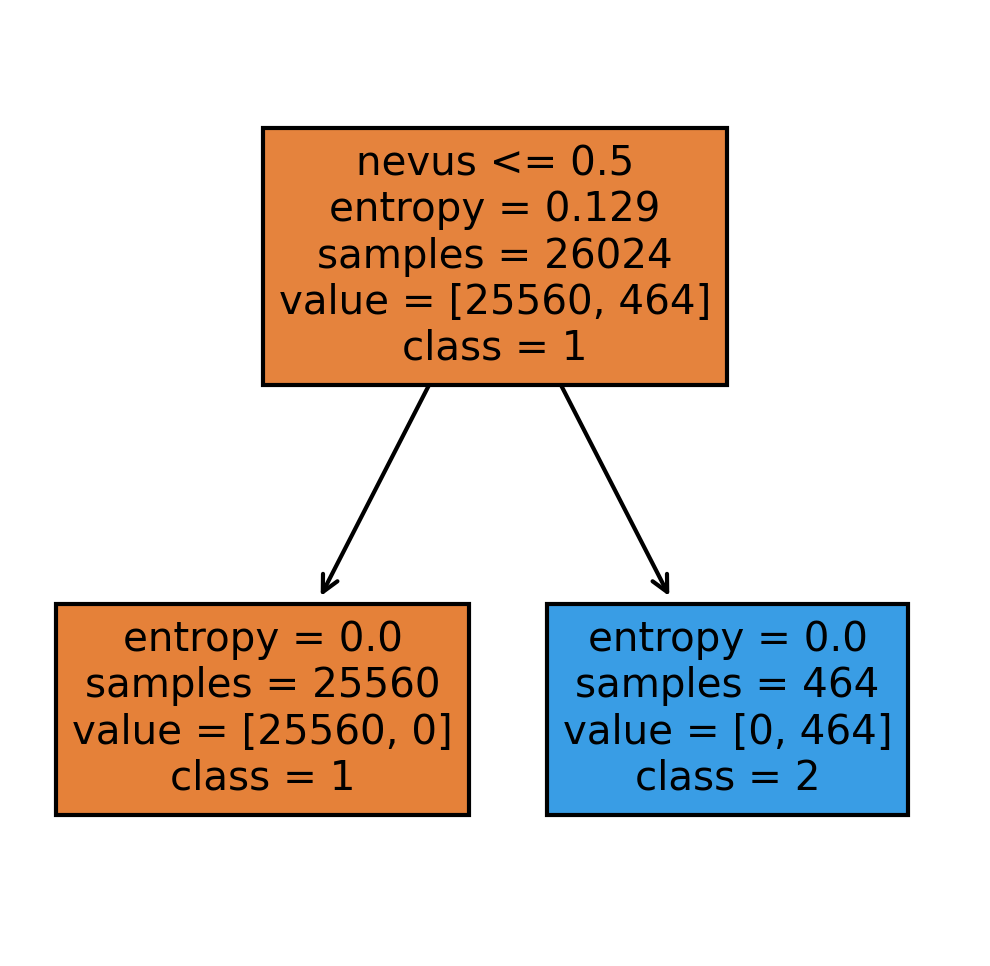

In [27]:
from sklearn import tree
import matplotlib.pyplot as plt

X = features.iloc[:,1:20]
#y = features.iloc[:,17]

fig, axes = plt.subplots(nrows = 1,ncols = 1,figsize = (4,4), dpi=300)
tree.plot_tree(clf,
               feature_names = X.columns, 
               class_names=['1','2','3','4','5','6','7'],
               filled = True);

In [33]:
from sklearn.svm import SVC
svc = SVC(kernel="linear")
svc.fit(X_train, y_train)


/usr/local/lib/python3.8/dist-packages/sklearn/utils/validation.py:993: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


SVC(kernel='linear')

In [35]:
print("Training accuracy of the model is {:.2f}".format(svc.score(X_train, y_train)))
print("Testing accuracy of the model is {:.2f}".format(svc.score(X_test, y_test)))

Training accuracy of the model is 1.00
Testing accuracy of the model is 1.00


In [37]:
predictions = svc.predict(X_test)
print(predictions)

[0 0 0 ... 0 0 0]


In [38]:
from sklearn.metrics import confusion_matrix
mat=confusion_matrix(predictions, y_test)
print(mat)

[[6396    0]
 [   0  111]]


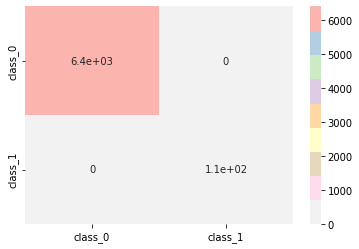

In [50]:
from seaborn import heatmap
heatmap(mat , cmap="Pastel1_r", xticklabels=['class_0' ,'class_1' ], yticklabels=['class_0' ,'class_1'], annot=True)

In [40]:
from sklearn.neural_network import MLPClassifier
nnc=MLPClassifier(hidden_layer_sizes=(7), activation="relu", max_iter=10000)

In [42]:
nnc.fit(X_train, y_train)

/usr/local/lib/python3.8/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:1109: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


MLPClassifier(hidden_layer_sizes=7, max_iter=10000)

In [44]:
print("The Training accuracy of the model is {:.2f}".format(nnc.score(X_train, y_train)))
print("The Testing accuracy of the model is {:.2f}".format(nnc.score(X_test, y_test)))

The Training accuracy of the model is 1.00
The Testing accuracy of the model is 1.00


In [45]:
predictions = nnc.predict(X_test)
print(predictions)

[0 0 0 ... 0 0 0]


In [48]:
from sklearn.metrics import confusion_matrix
mat=confusion_matrix(predictions, y_test)
print(mat)

[[6396    0]
 [   0  111]]


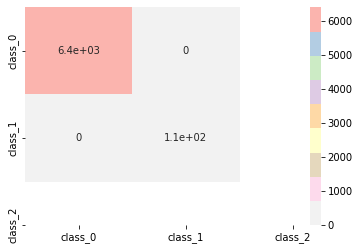

In [47]:
from seaborn import heatmap
heatmap(mat , cmap="Pastel1_r", xticklabels=['class_0' ,'class_1' ,'class_2'], yticklabels=['class_0' ,'class_1', 'class_2'], annot=True)